# "The effect of model resolution on air-sea CO$_{2}$ equilibration timescales "
## Code for Figures 5 b-e

Corresponding to Yinghuan Xie (yinghuan.xie@utas.edu.au)

In [1]:
# Importing the relevant modules.
import numpy as np
import xarray as xr
import math
import time
import datetime as dt
from datetime import timedelta
from datetime import datetime
import calendar
import os
import re
from glob import glob
#
import netCDF4 as nc
import pandas as pd
import gsw
#
import cartopy.crs as ccrs
from scipy.io import loadmat
#
import matplotlib.pyplot as plt
import matplotlib.colors as col
#
import cosima_cookbook as cc
session =cc.database.create_session()
expt = '01deg_jra55v13_ryf9091'
#
from os import sys
sys.path.append('/home/581/yx9454/PhD_Ch1')
from My_Py_Func import Ch1_defs as c1d

import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm

import cartopy.feature as cfeature
from PIL import Image, ImageSequence

import subprocess
from collections import defaultdict

# Declare and load global variables

In [2]:
area_regrid_1deg = np.load('/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/DIC_Cubic/area_regrid_1deg.npy')

# 360*180*50 Grid cell volume (in square meters)
st_ocean_50 = xr.open_dataset('/g/data/jk72/yx9454/PhD_Ch2/access-om2/archive/1deg_jra55_iaf_spin_up_step_5400s_ProbResolve_Site07_16_18_Control_2004/output018/ocean/ocean-3d-dzt-1-monthly-mean-ym_2004_01.nc').st_ocean.data
dzt_50 = np.diff(xr.open_dataset('/g/data/jk72/yx9454/PhD_Ch2/access-om2/archive/1deg_jra55_iaf_spin_up_step_5400s_ProbResolve_Site07_16_18_Control_2004/output018/ocean/ocean-3d-dzt-1-monthly-mean-ym_2004_01.nc').st_edges_ocean.data)
R = 6371000  # Earth's radius in meters
num_lon, num_lat = 360, 180  # Grid resolution
delta_lon_rad = np.deg2rad(360 / num_lon)  # Step size in radians
lat_edges_rad = np.deg2rad(np.linspace(-90, 90, num_lat + 1))  # Latitude edges in radians
area_regrid_1deg = (R**2 * delta_lon_rad * (np.sin(lat_edges_rad[1:]) - np.sin(lat_edges_rad[:-1]))[:, np.newaxis])
area_regrid_1deg = np.tile(area_regrid_1deg, (1, num_lon)) # Repeat area values for each longitude to create a 360x180 array
np.save('/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/DIC_Cubic/area_regrid_1deg.npy',area_regrid_1deg)

# Calculate the distance between latitudes (new code)
delta_lat_deg = 180 / num_lat  # Latitude degree interval
delta_lat_rad = np.deg2rad(delta_lat_deg)  # Latitude interval in radians

# Calculate the distance between latitudes (from equator to pole) (new code)
distance_lat = R * delta_lat_rad  # Distance for the latitude interval

# Calculate the distance between longitudes (new code)
delta_lon_deg = 360 / num_lon  # Longitude degree interval
delta_lon_rad = np.deg2rad(delta_lon_deg)  # Longitude interval in radians

# Initialize the distance array (new code)
distance_lon = np.zeros((num_lat, num_lon))  # Dimensions match the grid

# Calculate the distance for each longitude at each latitude layer (new code)
for i, lat_rad in enumerate(lat_edges_rad[:-1]):
    distance_lon[i, :] = R * np.cos(lat_rad) * delta_lon_rad

area_regrid_1deg_lon_dep = distance_lon
area_regrid_1deg_lat_dep = distance_lat*np.ones((180,50))*dzt_50

# Build region mask for all sites

In [4]:
Site_mask_dir = '/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/DIC_Cubic/'

group_site = {'4':'group_1','7':'group_1','12':'group_1',
              '5':'group_2','16':'group_2','17':'group_2',
              '6':'group_3','8':'group_3','18':'group_3',
              '3':'group_4','13':'group_4','21':'group_4',}

#exp_hemi =  {'02':'S','03':'N','04':  'S', '05': 'N','06':'S','07':'S','08':'N','09':'S','10':'S','11':'N','12':'S','13':'S', '16':'S','17':'N','18':'N','21':'N'}
exp_hemi =  {'2':'S','3':'N','4':  'S', '5': 'N','6':'S','7':'S','8':'N','9':'S','10':'S','11':'N','12':'S','13':'S', '16':'S','17':'N','18':'N','21':'N'}

visualization_range = {'lon_min':{'2':'S','3':0,'4':  -100, '5': -100,'6':-180,'7':-25,'8':30,'9':'S','10':'S','11':'N','12':-180,'13':-180, '16':-180,'17':-255,'18':-100,'21':-100},
                       'lon_max':{'2':'S','3':290,'4':  30, '5': 90,'6':180,'7':180,'8':290,'9':'S','10':'S','11':'N','12':180,'13':180, '16':180,'17':-75,'18':60,'21':100},
                       'lat_min':{'2':'S','3':-45,'4':  -30, '5': 30,'6':-80,'7':-60,'8':-40,'9':'S','10':'S','11':'N','12':-80,'13':-80, '16':-70,'17':0,'18':-10,'21':-15},
                       'lat_max':{'2':'S','3':70,'4':  90, '5': 90,'6':15,'7':30,'8':90,'9':'S','10':'S','11':'N','12':-30,'13':-10, '16':0,'17':66,'18':90,'21':90}}

# Assign lat-lon region box
######## Range: -90 - 90
lat_min   = {'2': -29, '3': 17, '4': -7.5, '5': 58, '6': -75, '7': -33, '8': 10, '9': -50, '10': -25, '11': 12.5, '12': -75, '13': -75, '16': -45, '17': 35, '18': 33, '21': 30}
lat_max   = {'2': -24, '3': 22, '4': 0, '5': 65, '6': -70, '7': -26, '8': 15, '9': -40, '10': -20, '11': 17.5, '12': -70, '13': -65, '16': -40, '17': 40, '18': 39, '21': 35}
######## Range -280 - 80
lon_min   = {'2': 151-360, '3': -158, '4': -40, '5': -22.5, '6': -180, '7': 111-360, '8': 112.5-360, '9': -77.5, '10': -49, '11': 70, '12': -50, '13': 65, '16': 143-360, '17': 140.5-360, '18': -11, '21': -82}
lon_max   = {'2': 157-360, '3': -153, '4': -35, '5': -17, '6': -165, '7': 117-360, '8': 117.5-360, '9': -70, '10': -38, '11': 77.5, '12': -35, '13': 80, '16': 150-360, '17': 145.5-360, '18': -6, '21': -75}


# Load ADIC and Sea Surface Velocity Files

In [3]:
def get_res_value(char):
    if char.startswith("1deg_j"):
        return '1'
    elif char.startswith("01deg_"):
        return '0.1'
    elif char.startswith("025deg"):
        return '0.25'
    else:
        return None
        
# Specify the directory and subdirectory names that you want to check
main_directory = '/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result'

tar_str = 'Normalizatied_180x360x50_DIC_deficit_'

if 'PACO2' in tar_str:
    unit = 'uatm'
    var_name = 'PACO2'
elif 'DIC' in tar_str:
    unit = 'mmol/m$^{2}$'
    var_name = 'ADIC'

# Initializes the result dictionary
Results_3Res_All_sites_Ver_Prof_Res_Comp = {}
Normalizatied_180x360_files = {'group_1': {}, 'group_2': {}, 'group_3': {},'group_4': {}}

# Define a list of lab directories
All_exp_dirs = [
    '1deg_jra55_iaf_spin_up_step_5400s_Group_1', '025deg_jra55_iaf_cycle_7_Group1', '01deg_jra55_iaf_group1_attempt_2',
    '1deg_jra55_iaf_spin_up_step_5400s_Group_2', '025deg_jra55_iaf_cycle_7_Group2', '01deg_jra55_iaf_group2',
    '1deg_jra55_iaf_spin_up_step_5400s_Group_3', '025deg_jra55_iaf_cycle_7_Group3', '01deg_jra55_iaf_group3',
    '1deg_jra55_iaf_spin_up_step_5400s_Group_4', '025deg_jra55_iaf_cycle_7_Group4', '01deg_jra55_iaf_Group4_3sites_adic_deficit_2004_07_01_07',
]

exp_name =  {'02':'Eastern Australia','03':'Hawaii','04':  'Amazon', '05': 'Iceland','06':'Ross Sea','07':'Western Australia','08':'South China Sea','09':'Chile','10':'Brazil','11':'Eastern India','12':'Weddell Sea','13':'Eastern Antarctica', '16':'Tasmania','17':'Kuroshio Current','18':'West of Gibraltar','21':'Gulf Stream'}

exp_sites =      {'group_1':['04','07','12'],
                  'group_2':['05','16','17'],
                  'group_3':['06','08','18'],
                  'group_4':['03','13','21']}

for file_path in All_exp_dirs:
    res = get_res_value(file_path[:6])

    if 'Group_1' in file_path or 'group1'  in file_path  or 'Group1' in file_path:
        group_key = 'group_1'
    elif 'Group_2' in file_path or 'group2' in file_path  or 'Group2'  in file_path:
        group_key = 'group_2'
    elif 'Group_3' in file_path or 'group3' in file_path  or 'Group3'  in file_path:
        group_key = 'group_3'
    elif 'Group_4' in file_path or 'group4' in file_path  or 'Group4'  in file_path:
        group_key = 'group_4'
    else:
        continue  # If no known groups are matched, skip this file path

    # Get the full path to the current lab directory (assuming your lab directory is in main_directory under the current working directory)
    full_path = os.path.join(os.getcwd(), main_directory+'/'+file_path)
    print(full_path)

    # Search for files that contain a specific pattern
    for file in os.listdir(full_path):
        if tar_str in file:
            # Check whether the resolution key value exists in the dictionary, and create it if it does not
            if res not in Normalizatied_180x360_files[group_key]:
                Normalizatied_180x360_files[group_key][res] = []
            
            # Add the file path to the corresponding resolution key
            Normalizatied_180x360_files[group_key][res].append(os.path.join(full_path, file))

/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/1deg_jra55_iaf_spin_up_step_5400s_Group_1
/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/025deg_jra55_iaf_cycle_7_Group1
/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/01deg_jra55_iaf_group1_attempt_2
/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/1deg_jra55_iaf_spin_up_step_5400s_Group_2
/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/025deg_jra55_iaf_cycle_7_Group2
/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/01deg_jra55_iaf_group2
/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/1deg_jra55_iaf_spin_up_step_5400s_Group_3
/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/025deg_jra55_iaf_cycle_7_Group3
/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/01deg_jra55_iaf_group3
/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/1deg_jra55_iaf_spin_up_step_5400s_Group_4
/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/025deg_jra55_iaf_cycle_7_Group4
/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/01deg_jra55_iaf_Group4_3sites_adic_deficit_2004_07_01_07


In [20]:
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm, BoundaryNorm
from matplotlib.colors import LinearSegmentedColormap
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

jet = plt.get_cmap('jet')
Number_of_colors = 6
colors = jet(np.linspace(0, 1, Number_of_colors))  # 从jet colormap中提取12种颜色
new_cmap = LinearSegmentedColormap.from_list('new_jet', colors, N=6)  # 创建一个新的 colormap，只有12种颜色


var_name = 'ADIC'
if var_name == 'ADIC':
    vmax = 1e3
    vmin = 1e-3

npz_file = np.load(Normalizatied_180x360_files['group_1']['1'][0])
lon_xy,lat_xy  = np.meshgrid(npz_file['longitude'],npz_file['latitude'])
lon_xz,dep_xz = np.meshgrid(npz_file['longitude'],npz_file['depth'])
lat_yz,dep_yz = np.meshgrid(npz_file['latitude'],npz_file['depth'])

In [6]:
output_dir = '/g/data/jk72/yx9454/GBC_Revision/'

# Initialize the reading result dictionary
speed_surface_mean_loaded = {}
speed_surface_mean_loaded_normalized = {}

# Resolution list
resolutions = ['1','0.25','0.1']

for model_res in resolutions:
    # Define the file path
    file_path = os.path.join(output_dir, f'surface_velocity_mean_{model_res}deg.nc')
    file_path2 = os.path.join(output_dir, f'Mean_Surf_Velocity_180x360_{model_res}_2004_1_to_2009_12.nc')
    # Read the NetCDF file
    ds = xr.open_dataarray(file_path).load()
    ds2 = xr.open_dataarray(file_path2).load()
    # Save to the dictionary
    speed_surface_mean_loaded[model_res] = ds
    speed_surface_mean_loaded_normalized[model_res] = ds2
    print(f"Loaded surface mean speed for {model_res} degree from {file_path}")

print("All files successfully loaded.")

Loaded surface mean speed for 1 degree from /g/data/jk72/yx9454/GBC_Revision/surface_velocity_mean_1deg.nc
Loaded surface mean speed for 0.25 degree from /g/data/jk72/yx9454/GBC_Revision/surface_velocity_mean_0.25deg.nc
Loaded surface mean speed for 0.1 degree from /g/data/jk72/yx9454/GBC_Revision/surface_velocity_mean_0.1deg.nc
All files successfully loaded.


# Plotting Figure 5 b-d

## Style 1

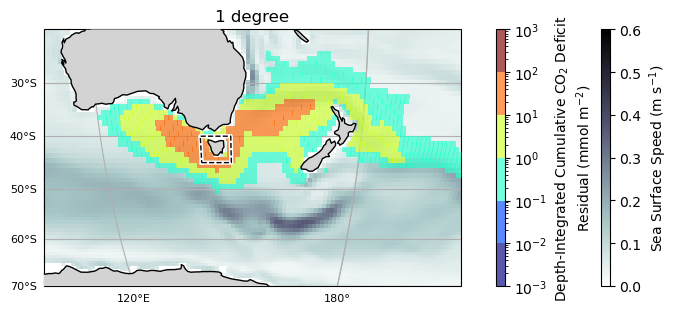

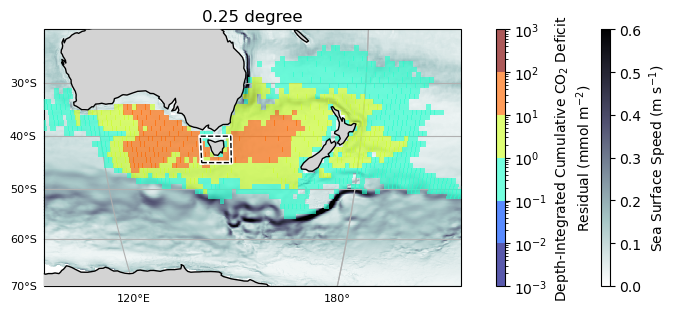

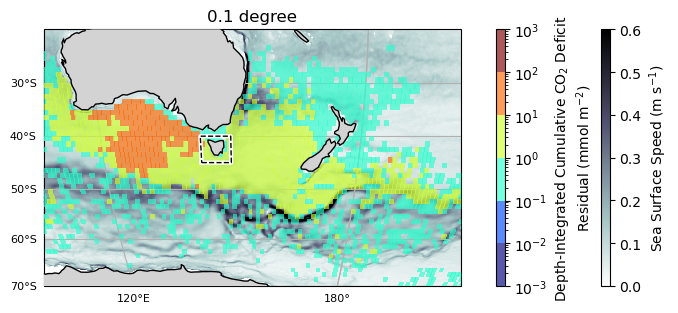

In [32]:
save_dir = '/home/581/yx9454/GBC_Revision/'

resolutions = ['1','0.25','0.1'] # 1 0.25 0.1

cbar_dep_to_lat_ratio = 1000
cbar_dep_to_lon_ratio = 1000

save_flag = True
for site in ['16']:
    for resolution in resolutions:
        target_file = [f for f in Normalizatied_180x360_files['group_2'][resolution] if '2007_12' in f][0]
        target_file = np.load(target_file)
        mask = np.load(Site_mask_dir + 'Site_mask_' + str(site) + '_180_360.npy')
        deficit = target_file['data']
        deficit[:, ~mask] = np.nan
        tar = np.nansum(deficit, axis=0) / area_regrid_1deg
        tar[tar == 0] = np.nan
        tar_full  = tar.copy()
        tar[tar < 1e-1] = np.nan
        
        fig = plt.figure(figsize=(16/1.5,8*1.25/2/1.5))
        # Fixed drawing area：Tasmania & New Zealand region
        projection = ccrs.Robinson(central_longitude=155)
        ax = plt.axes(projection=projection)
        ax.set_extent([110, 200, -70, -20], crs=ccrs.PlateCarree())
        # Add coastlines and land, and place them on the top layer
        ax.add_feature(cfeature.LAND, zorder=20, facecolor='lightgrey')
        ax.coastlines(zorder=21)
        
        # Draw the deficit (concentration) pcolormesh
        mesh = ax.pcolormesh(
            lon_xy, lat_xy, tar,
            transform=ccrs.PlateCarree(),
            zorder=10,
            norm=LogNorm(vmin=vmin, vmax=vmax),
            cmap=new_cmap,alpha=0.65
        )

        # The first colorbar is slightly to the right of the right
        cbar1 = plt.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.02, pad=-0.15, aspect=30)
        cbar1.set_label("Depth-Integrated Cumulative CO$_2$ Deficit\nResidual (mmol m$^{-2}$)")

        # Draw speed background
        speed = speed_surface_mean_loaded[resolution]
        speed_plot = speed.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            vmin=0, vmax=0.60,
            cmap='bone_r',
            add_colorbar=False,
            zorder=0
        )
        
        # Further to the right of the second colorbar
        cbar2 = plt.colorbar(speed_plot, ax=ax, orientation='vertical', fraction=0.02, pad=0.15, aspect=30)
        cbar2.set_label('Sea Surface Speed (m s$^{-1}$)')

        # Add the longitude and latitude coordinate scale
        gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size':8}
        gl.ylabel_style = {'size':8}

        # Coordinates of the first rectangle
        lons_1 = [lon_min[site], lon_max[site], lon_max[site], lon_min[site], lon_min[site]]
        lats_1 = [lat_min[site], lat_min[site], lat_max[site], lat_max[site], lat_min[site]]
        
        # Plot the first rectangle boundary with white color, solid line, linewidth=3
        ax.plot(lons_1, lats_1, color='white', linestyle='-', linewidth=3, transform=ccrs.PlateCarree(),zorder=10)
        ax.plot(lons_1, lats_1, color='k', linestyle='--', linewidth=1, transform=ccrs.PlateCarree(),zorder=11)

        plt.title(f"{resolution} degree")
        # save
        if save_flag:
            plt.savefig(f"{save_dir}DIC_Deficit_Plus_Velocity_Site_{site}_Res_{resolution}.png", dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

## Style 2

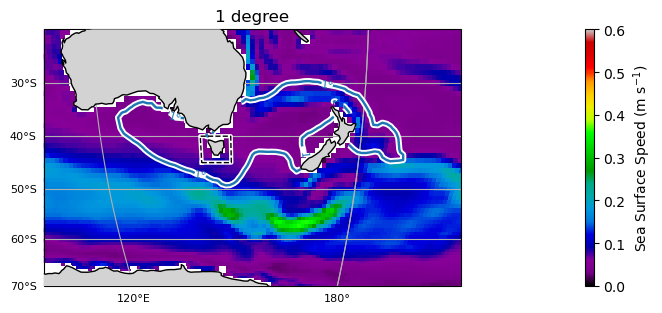

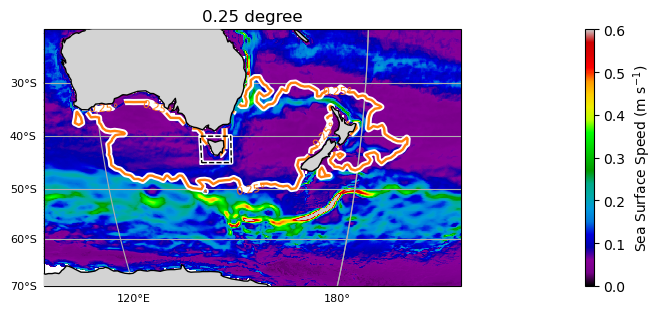

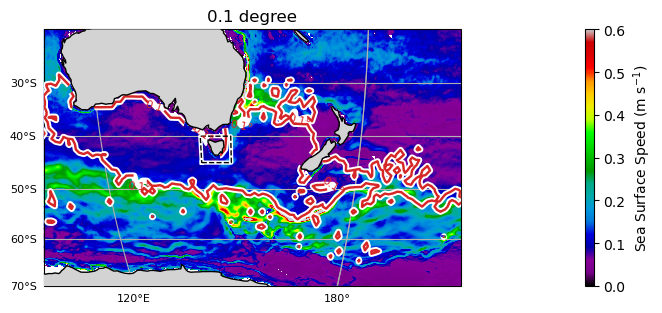

In [37]:
resolutions = ['1','0.25','0.1'] # 1 0.25 0.1

cbar_dep_to_lat_ratio = 1000
cbar_dep_to_lon_ratio = 1000

save_flag = True
for site in ['16']:
    for resolution in resolutions:
        target_file = [f for f in Normalizatied_180x360_files['group_2'][resolution] if '2007_12' in f][0]
        target_file = np.load(target_file)
        mask = np.load(Site_mask_dir + 'Site_mask_' + str(site) + '_180_360.npy')
        deficit = target_file['data']
        deficit[:, ~mask] = np.nan
        tar = np.nansum(deficit, axis=0) / area_regrid_1deg
        tar[tar == 0] = np.nan
        tar_full  = tar.copy()
        tar[tar < 1e-1] = np.nan
        
        fig = plt.figure(figsize=(16/1.5,8*1.25/2/1.5))
        # Fixed drawing area：Tasmania & New Zealand region
        projection = ccrs.Robinson(central_longitude=155)
        ax = plt.axes(projection=projection)
        ax.set_extent([110, 200, -70, -20], crs=ccrs.PlateCarree())
        # Add coastlines and land, and place them on the top layer
        ax.add_feature(cfeature.LAND, zorder=20, facecolor='lightgrey')
        ax.coastlines(zorder=21)
        
        # Draw contour，Mark the contour line with a value of 1
        contour = ax.contour(
            lon_xy, lat_xy, tar_full,
            levels=[1e0],  # Only draw contour lines with a value of 1
            colors=colors[resolution],  # Contour line color
            linewidths=1.75,
            transform=ccrs.PlateCarree(),
            zorder=11
        )

        contour_bg = ax.contour(
            lon_xy, lat_xy, tar_full,
            levels=[1e0],  # Only draw contour lines with a value of 1
            colors='white',  # Contour line color
            linewidths=4.5,
            transform=ccrs.PlateCarree(),
            zorder=10
        )
        
        # Add labels on the contour contour lines
        ax.clabel(
            contour,
            fmt={1e0: f'{resolution}°'},  # Format the label content to resolution + °
            fontsize=8
        )

        # Draw speed background
        speed = speed_surface_mean_loaded[resolution]
        speed_plot = speed.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            vmin=0, vmax=0.60,
            cmap='nipy_spectral',
            add_colorbar=False,
            zorder=0
        )
        
        # Further to the right of the second colorbar
        cbar2 = plt.colorbar(speed_plot, ax=ax, orientation='vertical', fraction=0.02, pad=0.15, aspect=30)
        cbar2.set_label('Sea Surface Speed (m s$^{-1}$)')

        # Add the longitude and latitude coordinate scale
        gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size':8}
        gl.ylabel_style = {'size':8}

        # Coordinates of the first rectangle
        lons_1 = [lon_min[site], lon_max[site], lon_max[site], lon_min[site], lon_min[site]]
        lats_1 = [lat_min[site], lat_min[site], lat_max[site], lat_max[site], lat_min[site]]
        
        # Plot the first rectangle boundary with white color, solid line, linewidth=3
        ax.plot(lons_1, lats_1, color='white', linestyle='-', linewidth=3, transform=ccrs.PlateCarree(),zorder=10)
        ax.plot(lons_1, lats_1, color='k', linestyle='--', linewidth=1, transform=ccrs.PlateCarree(),zorder=11)

        plt.title(f"{resolution} degree")
        # save
        if save_flag:
            plt.savefig(f"{save_dir}DIC_Deficit_Plus_Velocity_Site_{site}_Res_{resolution}_v2.png", dpi=300, bbox_inches='tight') 
        plt.show()
        plt.close()

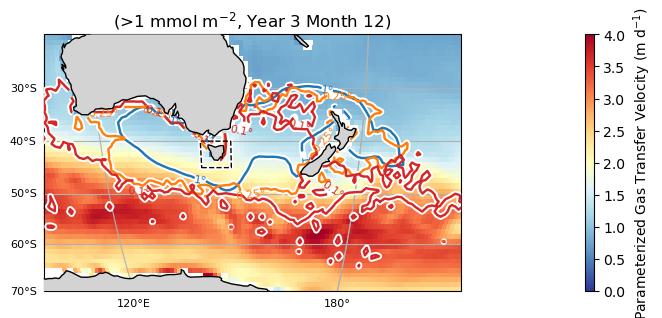

In [35]:
resolutions = ['1','0.25','0.1'] # 1 0.25 0.1
colors = {'1':'C0','0.25':'C1','0.1':'C3'}
cbar_dep_to_lat_ratio = 1000
cbar_dep_to_lon_ratio = 1000

save_flag = True
for site in ['16']:
    fig = plt.figure(figsize=(16/1.5,8*1.25/2/1.5))

    projection = ccrs.Robinson(central_longitude=155)
    ax = plt.axes(projection=projection)
    ax.set_extent([110, 200, -70, -20], crs=ccrs.PlateCarree())
    # Add coastlines and land, and place them on the top layer
    ax.add_feature(cfeature.LAND, zorder=20, facecolor='lightgrey')
    ax.coastlines(zorder=21)

    # Draw speed background
    kddic = xr.open_dataset('/home/581/yx9454/GBC_Revision/Monthly_k_ddic_180x360_1_2004_1_to_2008_12.nc')
    kddic = kddic.dDIC_dCO2
    kddic = kddic.mean(dim='time')
    kddic_plot = kddic.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        vmin=0, vmax=4.0,
        cmap='RdYlBu_r',
        add_colorbar=False,
        zorder=0
    )
        
    for resolution in resolutions:
        
        # Fixed drawing area：Tasmania & New Zealand region
        
        target_file = [f for f in Normalizatied_180x360_files['group_2'][resolution] if '2007_12' in f][0]
        target_file = np.load(target_file)
        
        mask = np.load(Site_mask_dir + 'Site_mask_' + str(site) + '_180_360.npy')
        
        deficit = target_file['data']
        deficit[:, ~mask] = np.nan
        tar = np.nansum(deficit, axis=0) / area_regrid_1deg
        tar[tar == 0] = np.nan
        tar_full  = tar.copy()

        # Draw a contour and mark the contour lines with a value of 1
        contour = ax.contour(
            lon_xy, lat_xy, tar_full,
            levels=[1e0],  # Only draw contour lines with a value of 1
            colors=colors[resolution],  # Contour line color
            linewidths=1.75,
            transform=ccrs.PlateCarree(),
            zorder=11
        )

        contour_bg = ax.contour(
            lon_xy, lat_xy, tar_full,
            levels=[1e0],  # Only draw contour lines with a value of 1
            colors='white',  # Contour line color
            linewidths=4.5,
            transform=ccrs.PlateCarree(),
            zorder=10
        )
        
        # Add labels on the contour contour lines
        ax.clabel(
            contour,
            fmt={1e0: f'{resolution}°'},  # Format the label content to resolution + °
            fontsize=8
        )
        
    # 添加经纬度坐标刻度
    gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size':8}
    gl.ylabel_style = {'size':8}

    # Coordinates of the first rectangle
    lons_1 = [lon_min[site], lon_max[site], lon_max[site], lon_min[site], lon_min[site]]
    lats_1 = [lat_min[site], lat_min[site], lat_max[site], lat_max[site], lat_min[site]]
        
    # Plot the first rectangle boundary with white color, solid line, linewidth=3
    ax.plot(lons_1, lats_1, color='white', linestyle='-', linewidth=3, transform=ccrs.PlateCarree(),zorder=10)
    ax.plot(lons_1, lats_1, color='k', linestyle='--', linewidth=1, transform=ccrs.PlateCarree(),zorder=11)

    # Further to the right of the second colorbar
    cbar2 = plt.colorbar(kddic_plot, ax=ax, orientation='vertical', fraction=0.02, pad=0.15, aspect=30)
    cbar2.set_label('Parameterized Gas Transfer Velocity (m d$^{-1}$)')

    plt.title(f"(>1 mmol m$^{{-2}}$, Year 3 Month 12)")
    
    # save
    if save_flag:
        plt.savefig(f"{save_dir}DIC_Deficit_Contour_Plus_Kddic_Site_{site}_ALL_Res.png", dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()